In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, accuracy_score)
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
df = pd.read_csv("../data/dataset_preprocesado.csv")

print(f"Shape: {df.shape}")
print(f"Reales: {df[df['label']==1].shape[0]} | Falsas: {df[df['label']==0].shape[0]}")
df.head(3)

Shape: (44889, 5)
Reales: 21417 | Falsas: 23472


,title,text,subject,label,content
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,0,break gop chairman grassley enough demand trum...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,0,fail gop candid rememb hilari mock eulog video...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,0,mike penc new dc neighbor hilari troll homopho...


In [3]:
X = df["content"]
y = df["label"]

# TF-IDF: convierte texto en vectores numéricos
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

# 80% entrenamiento, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 35911 muestras
Test:  8978 muestras


In [4]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM":          LinearSVC(max_iter=1000),
    "Naive Bayes":         MultinomialNB(),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    print(f"\n⏳ Entrenando {nombre}...")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = {"modelo": modelo, "y_pred": y_pred, "accuracy": acc}
    print(f"✅ {nombre}: Accuracy = {acc:.4f}")



⏳ Entrenando Logistic Regression...
✅ Logistic Regression: Accuracy = 0.9908

⏳ Entrenando Linear SVM...
✅ Linear SVM: Accuracy = 0.9959

⏳ Entrenando Naive Bayes...
✅ Naive Bayes: Accuracy = 0.9521

⏳ Entrenando Random Forest...
✅ Random Forest: Accuracy = 0.9979


In [5]:
tabla = pd.DataFrame([
    {
        "Modelo": nombre,
        "Accuracy": f"{datos['accuracy']*100:.2f}%"
    }
    for nombre, datos in resultados.items()
])

print(tabla.to_string(index=False))

             Modelo Accuracy
Logistic Regression   99.08%
         Linear SVM   99.59%
        Naive Bayes   95.21%
      Random Forest   99.79%


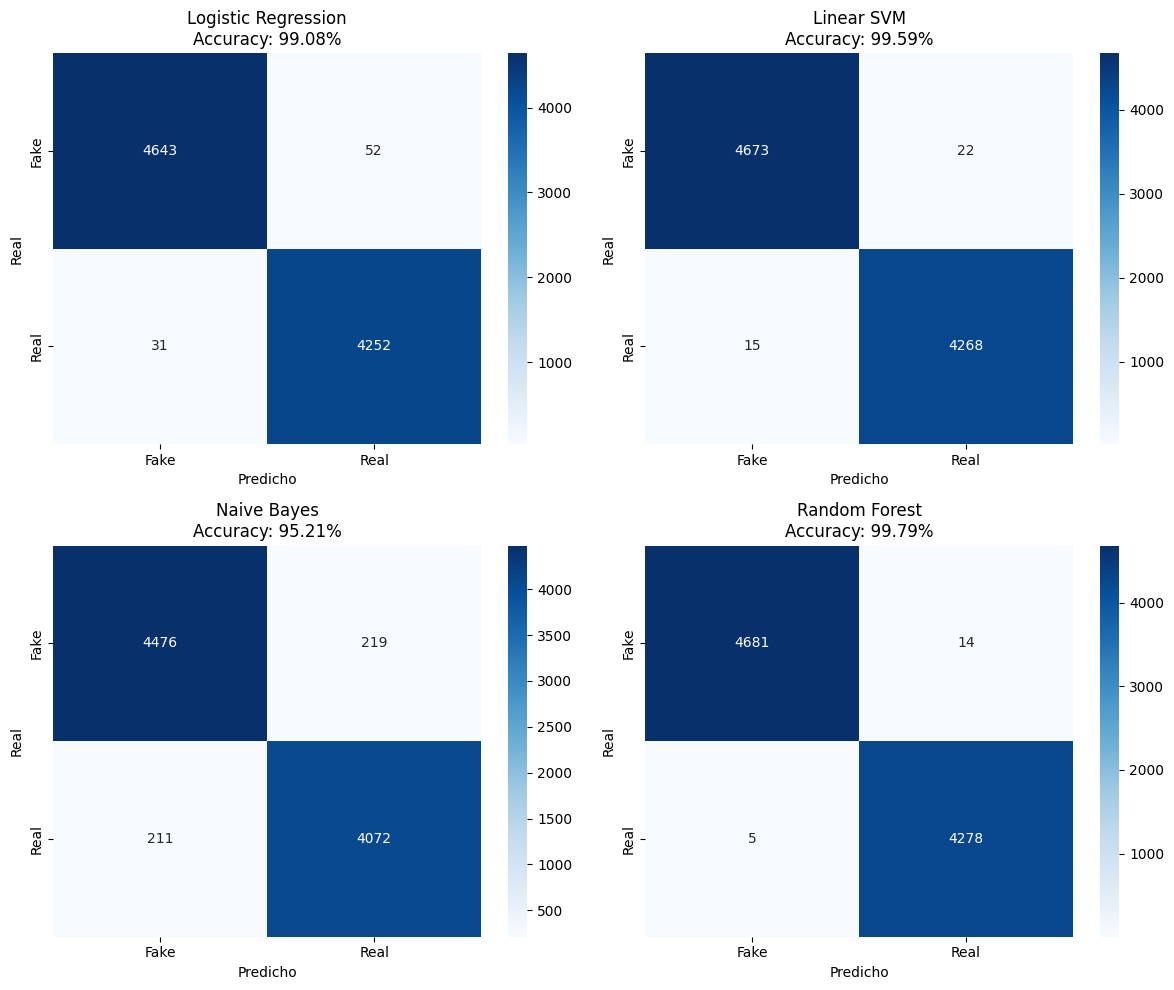

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (nombre, datos) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, datos["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Fake", "Real"],
                yticklabels=["Fake", "Real"])
    axes[i].set_title(f"{nombre}\nAccuracy: {datos['accuracy']*100:.2f}%")
    axes[i].set_xlabel("Predicho")
    axes[i].set_ylabel("Real")

plt.tight_layout()
plt.savefig("../outputs/matrices_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

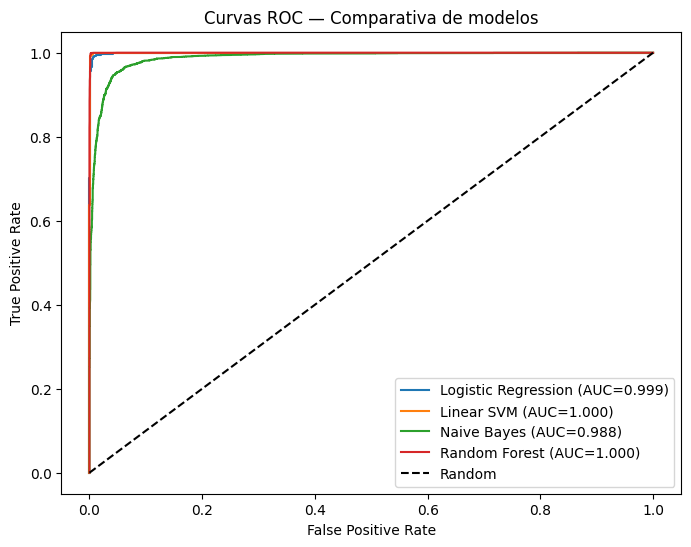

In [7]:
plt.figure(figsize=(8, 6))

for nombre, datos in resultados.items():
    modelo = datos["modelo"]
    # Naive Bayes y LR tienen predict_proba, SVM no
    if hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(X_test)[:, 1]
    else:
        y_prob = modelo.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — Comparativa de modelos")
plt.legend()
plt.savefig("../outputs/curvas_roc.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
mejor = max(resultados, key=lambda k: resultados[k]["accuracy"])
print(f"🏆 Mejor modelo: {mejor}\n")
print(classification_report(y_test, resultados[mejor]["y_pred"],
                            target_names=["Fake", "Real"]))

🏆 Mejor modelo: Random Forest

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4695
        Real       1.00      1.00      1.00      4283

    accuracy                           1.00      8978
   macro avg       1.00      1.00      1.00      8978
weighted avg       1.00      1.00      1.00      8978



In [9]:
mejor_modelo = resultados[mejor]["modelo"]

with open("../models/mejor_modelo.pkl", "wb") as f:
    pickle.dump(mejor_modelo, f)

with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print(f"✅ Modelo guardado: {mejor}")
print("✅ Vectorizador TF-IDF guardado")

✅ Modelo guardado: Random Forest
✅ Vectorizador TF-IDF guardado


In [10]:
import pickle
import pandas as pd

# Cargar modelo y vectorizador
with open("../models/mejor_modelo.pkl", "rb") as f:
    modelo = pickle.load(f)

with open("../models/tfidf_vectorizer.pkl", "rb") as f:
    tfidf = pickle.load(f)

# Coger 10 noticias REALES del dataset original
df = pd.read_csv("../data/dataset_preprocesado.csv")
muestra_real = df[df["label"] == 1]["content"].head(10)

# Ver qué confianza les da el modelo
vectores = tfidf.transform(muestra_real)
probs = modelo.predict_proba(vectores)

for i, prob in enumerate(probs):
    print(f"Noticia {i+1} → FAKE: {prob[0]:.2f} | REAL: {prob[1]:.2f} | Predicción: {'REAL' if prob[1] > 0.5 else 'FAKE'}")

Noticia 1 → FAKE: 0.04 | REAL: 0.96 | Predicción: REAL
Noticia 2 → FAKE: 0.02 | REAL: 0.98 | Predicción: REAL
Noticia 3 → FAKE: 0.04 | REAL: 0.96 | Predicción: REAL
Noticia 4 → FAKE: 0.10 | REAL: 0.90 | Predicción: REAL
Noticia 5 → FAKE: 0.06 | REAL: 0.94 | Predicción: REAL
Noticia 6 → FAKE: 0.08 | REAL: 0.92 | Predicción: REAL
Noticia 7 → FAKE: 0.00 | REAL: 1.00 | Predicción: REAL
Noticia 8 → FAKE: 0.10 | REAL: 0.90 | Predicción: REAL
Noticia 9 → FAKE: 0.16 | REAL: 0.84 | Predicción: REAL
Noticia 10 → FAKE: 0.08 | REAL: 0.92 | Predicción: REAL
